# Accretion-ejection instability

$(\omega - m\Omega_\theta)^2 = \Omega_r^2 + \frac{2B_0 |k|}{\Sigma r} + \frac{k^2 c_s^2}{r}$

- $B_0$ campo imperturbato, prpendicolare al disco. legato al materiale del disco - assumiamo legge di potenza con esponenti 0.5, 1, 1.5
- $\Sigma$ densità superficiale, stessa legge radiale di B perché campo legato a questa direttamente.
- assumo disco sottile, con aspect ratio $H/r = 0.05$
- $c_s$ velocità del suono - in disco sottile è dato approssimativamente dalla formula sotto
- k = numero d'onda. loi prendiamo come parametro liberto ma poi controlliamo che stia in range ragionevole ($k \approx 1/H$ con H scala verticale tipica del disco)
- m generalmente il modo eccitato ha un solo braccio, perciò poniamo m=1 per ridurre il numro di parametri


> $B_0 = B_{00} (r/r_{in})^{-\alpha}$

> $\Sigma = \Sigma_0 (r/r_{in})^{-\alpha}$

> $c_s \approx (H/r) v_\varphi = (H/r) r \Omega_\varphi$

> $0.1/r < |k| < 10/r$

dato che l'equazione è una quadratica in |K| risolviamo analiticamente per omega=target. troviamo quindi 

$k(B_{00}, r, \Sigma_0, a)$

con $m = 1, h/r = 0.05, \alpha = 0.5$, M_BH$ fissati

## setup

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from setup import *
from plts_funcs import *

In [18]:
# parametri fissati
mm = 1
alp = 0.5
hor = 0.05

### Profili Radiali

In [19]:
# ========================================================================
# PROFILI RADIALI
# ========================================================================

def B0_profile(r, a, B00, alpha_exp):
    """
    Campo magnetico: B₀(r) = B₀₀ × (r/r_in)^(-α)
    
    Parameters:
    -----------
    r : array_like
        Radius in gravitational radii
    a : array_like
        Dimensionless spin
    B00 : float
        Normalization at r_in
    alpha_exp : float
        Power-law exponent
    
    Returns:
    --------
    B0 : array_like
        Magnetic field (arbitrary units)
    """
    r = np.asarray(r)
    a = np.asarray(a)
    
    r_in = r_isco(a)
    return B00 * (r / r_in)**(-alpha_exp)


def Sigma_profile(r, a, Sigma0, alpha_exp):
    """
    Surface density: Σ(r) = Σ₀ × (r/r_in)^(-α)
    
    Returns:
    --------
    Sigma : array_like
        Surface density (arbitrary units)
    """
    r = np.asarray(r)
    a = np.asarray(a)
    
    r_in = r_isco(a)
    return Sigma0 * (r / r_in)**(-alpha_exp)


def sound_speed_thin(r, a, hr=0.05, M=M_BH):
    """
    Sound speed in thin disk: c_s ≈ (H/r) × v_φ = (H/r) × r × Ω_φ
    
    Parameters:
    -----------
    hr : float
        Aspect ratio H/r (default: 0.05)
    
    Returns:
    --------
    c_s : array_like
        Sound speed in cm/s
    """
    r = np.asarray(r)
    a = np.asarray(a)
    M = np.asarray(M)
    
    # v_φ = r × Ω_φ = r × (2π ν_φ)
    # Ma ν_φ è già in Hz, quindi v_φ in cm/s è:
    Rg = Rg_SUN * M  # cm
    v_phi = 2 * np.pi * nu_phi(r, a, M) * r * Rg  # cm/s
    
    return hr * v_phi

### Solver Analitico per k

In [20]:
# ========================================================================
# SOLVER ANALITICO PER k
# ========================================================================

def solve_k_rossby(r, a, B00, Sigma0, alpha_exp=alp, m=mm, hr=hor, M=M_BH):
    """
    Solve for |k| from Rossby wave dispersion relation:
    
    (ω̃ + m·Ω_φ)² = κ² + (2B₀²/Σ)|k| + k²c_s²
    
    This is a quadratic in |k|:
    c_s² × |k|² + (2B₀²/Σ) × |k| + (κ² - ω²) = 0
    
    where ω = ω̃ + m·Ω_φ
    
    Parameters:
    -----------
    r, a, B00, Sigma0, alpha_exp : array_like
        Physical parameters (can be meshgrid arrays)
    m : int
        Azimuthal mode number (default: 1)
    hr : float
        Aspect ratio H/r (default: 0.05)
    
    Returns:
    --------
    k_solutions : dict
        'k_plus': larger solution
        'k_minus': smaller solution
        'valid': boolean mask where solutions are real and positive
    """
    r = np.asarray(r)
    a = np.asarray(a)
    B00 = np.asarray(B00)
    Sigma0 = np.asarray(Sigma0)
    alpha_exp = np.asarray(alpha_exp)
    
    # Compute profiles
    B0 = B0_profile(r, a, B00, alpha_exp)
    Sigma = Sigma_profile(r, a, Sigma0, alpha_exp)
    c_s = sound_speed_thin(r, a, hr, M)
    kappa_sq = (2 * np.pi * nu_r(r, a, M))**2  # rad²/s²
    
    # Target frequency in frame: ω = ω̃ + m·Ω_φ
    omega = 2 * np.pi * NU0  # rad/s (observed frequency)
    Omega_phi = 2 * np.pi * nu_phi(r, a, M)  # rad/s
    omega_tilde = omega - m * Omega_phi
    omega_sq = omega_tilde**2
    
    Rg = Rg_SUN * M  # cm
    r_cm = r * Rg
    
    # Quadratic coefficients: A|k|² + B|k| + C = 0
    A = c_s**2 / r**2
    B = 2 * B0**2 / Sigma / r
    C = kappa_sq - omega_sq
    
    # Discriminant
    Delta = B**2 - 4*A*C
    
    # Solutions
    k_plus = np.zeros_like(r)
    k_minus = np.zeros_like(r)
    valid = np.zeros_like(r, dtype=bool)
    
    # Only compute where discriminant is non-negative
    mask = Delta >= 0
    
    if np.any(mask):
        sqrt_Delta = np.sqrt(Delta[mask])
        k_plus[mask] = (-B[mask] + sqrt_Delta) / (2*A[mask])
        k_minus[mask] = (-B[mask] - sqrt_Delta) / (2*A[mask])
        
        # Keep only positive solutions
        valid[mask] = (k_plus[mask] > 0) | (k_minus[mask] > 0)
    
    return {
        'k_plus': k_plus,
        'k_minus': k_minus,
        'valid': valid,
        'Delta': Delta,
        'B0': B0,
        'Sigma': Sigma,
        'c_s': c_s
    }

### Check Fisici

In [21]:
# ========================================================================
# FUNZIONI PER I CHECK FISICI
# ========================================================================

def check_k_physical(k, r, k_min_factor=0.1, k_max_factor=10):
    """
    Check if k is in physical range: k_min/r < |k| < k_max/r
    
    For thin disk with H ~ 0.05r, we expect k ~ 1/H ~ 20/r
    We allow a range [0.1/r, 10/r] to be conservative
    
    Returns:
    --------
    mask : boolean array
        True where k is physical
    """
    k = np.asarray(k)
    r = np.asarray(r)
    
    k_min = k_min_factor / r
    k_max = k_max_factor / r
    
    return (k >= k_min) & (k <= k_max)


def compute_beta(r, a, B00, Sigma0, alpha_exp=alp, hr=hor, M=M_BH):
    """
    Compute plasma beta: β = 8π Σ c_s² / (H B₀²)
    
    For AEI instability, we need β ≤ 1 (magnetic pressure dominated)
    
    Returns:
    --------
    beta : array_like
        Plasma beta parameter
    """
    r = np.asarray(r)
    a = np.asarray(a)
    B00 = np.asarray(B00)
    Sigma0 = np.asarray(Sigma0)
    
    B0 = B0_profile(r, a, B00, alpha_exp)
    Sigma = Sigma_profile(r, a, Sigma0, alpha_exp)
    c_s = sound_speed_thin(r, a, hr, M)
    
    Rg = Rg_SUN * M  # cm
    H = hr * r * Rg  # cm
    
    beta = 8 * np.pi * Sigma * c_s**2 / (H * B0**2)
    
    return beta


def check_beta_AEI(r, a, B00, Sigma0, alpha_exp=alp, hr=hor, M=M_BH, beta_max=1.0):
    """
    Check if β ≤ beta_max (condition for AEI instability)
    
    Returns:
    --------
    mask : boolean array
        True where β ≤ beta_max
    """
    beta = compute_beta(r, a, B00, Sigma0, alpha_exp, hr, M)
    return beta <= beta_max


def compute_shear_quantity(r, a, B00, Sigma0, alpha_exp=alp, M=M_BH):
    """
    Compute Q = Ωφ × Σ / B₀²
    
    For AEI, we need dQ/dr > 0
    
    Returns:
    --------
    Q : array_like
        Shear quantity
    """
    r = np.asarray(r)
    a = np.asarray(a)
    B00 = np.asarray(B00)
    Sigma0 = np.asarray(Sigma0)
    
    # Compute profiles
    B0 = B0_profile(r, a, B00, alpha_exp)
    Sigma = Sigma_profile(r, a, Sigma0, alpha_exp)
    Omega_phi = 2 * np.pi * nu_phi(r, a, M)  # rad/s
    
    Q = Omega_phi * Sigma / B0**2
    
    return Q


def check_shear_positive(r, a, B00, Sigma0, alpha_exp=alp, M=M_BH, dr_factor=0.01):
    """
    Check if dQ/dr > 0 using finite differences
    
    Parameters:
    -----------
    dr_factor : float
        Fractional step size for finite difference: dr = dr_factor * r
    
    Returns:
    --------
    mask : boolean array
        True where dQ/dr > 0
    """
    r = np.asarray(r)
    a = np.asarray(a)
    B00 = np.asarray(B00)
    Sigma0 = np.asarray(Sigma0)
    
    # Compute Q at r and r + dr
    dr = dr_factor * r
    Q_r = compute_shear_quantity(r, a, B00, Sigma0, alpha_exp, M)
    Q_rp = compute_shear_quantity(r + dr, a, B00, Sigma0, alpha_exp, M)
    
    # Finite difference derivative
    dQ_dr = (Q_rp - Q_r) / dr
    
    return dQ_dr > 0

### matching

In [22]:
# ========================================================================
# FUNZIONE DI MATCHING CON OPZIONI PER I CHECK FISICI
# ========================================================================

def find_rossby_matches(param_dict, use_k_plus=True, 
                       check_k=False, check_beta=False, check_shear=False,
                       m=mm, hr=hor, alpha_exp=alp):
    """
    Find parameter combinations that produce Rossby waves at target frequency.
    
    Parameters:
    -----------
    param_dict : dict
        Parameter grid definition for create_param_grid()
        Must include: 'r', 'a', 'B00', 'Sigma0'
    use_k_plus : bool
        If True, use k_plus solution; if False, use k_minus
    check_k : bool
        If True, apply physical k constraint
    check_beta : bool
        If True, apply β ≤ 1 constraint
    check_shear : bool
        If True, apply dQ/dr > 0 constraint
    m : int
        Azimuthal mode number
    hr : float
        Aspect ratio H/r
    alpha_exp : float
        Power-law exponent for B0 and Sigma profiles
    
    Returns:
    --------
    df : DataFrame
        Matched solutions with columns for all parameters plus 'k', 'beta', 'dQ_dr'
    """
    # Create parameter grid
    param_vectors, mesh_arrays = create_param_grid(param_dict, mesh=True)
    labels = list(param_dict.keys())
    
    # Extract meshgrid arrays
    param_mesh = {lab: arr for lab, arr in zip(labels, mesh_arrays)}
    
    r = param_mesh['r']
    a = param_mesh['a']
    B00 = param_mesh['B00']
    Sigma0 = param_mesh['Sigma0']
    
    # Solve for k
    k_sols = solve_k_rossby(r, a, B00, Sigma0, alpha_exp, m=m, hr=hr)
    
    # Choose which solution to use
    k = k_sols['k_plus'] if use_k_plus else k_sols['k_minus']
    
    # Build mask
    mask = k_sols['valid']
    
    # Apply ISCO constraint
    a_vec = param_vectors['a']
    isco = r_isco(a_vec)
    r_isco_nd = isco.reshape(-1, *[1]*(r.ndim - 1))
    mask &= (r >= r_isco_nd)
    
    # Collect results
    Rg = Rg_SUN * M_BH  # cm to convert k from 1/cm to 1/rg
    k = k * Rg  # convert k from 1/cm to 1/rg
    
    # Compute additional quantities for all points
    beta = compute_beta(r, a, B00, Sigma0, alpha_exp, hr)
    Q = compute_shear_quantity(r, a, B00, Sigma0, alpha_exp)
    
    # Compute derivative of Q
    dr_factor = 0.01
    dr = dr_factor * r
    Q_rp = compute_shear_quantity(r + dr, a, B00, Sigma0, alpha_exp)
    dQ_dr = (Q_rp - Q) / dr
    
    # Apply physical constraints if requested
    if check_k:
        mask &= check_k_physical(k, r)
    
    if check_beta:
        mask &= check_beta_AEI(r, a, B00, Sigma0, alpha_exp, hr)
    
    if check_shear:
        mask &= check_shear_positive(r, a, B00, Sigma0, alpha_exp)
    
    rows = []
    idxs = np.argwhere(mask)
    
    for idx in idxs:
        idx_tuple = tuple(idx)
        row = {lab: arr[idx_tuple] for lab, arr in param_mesh.items()}
        row['k'] = k[idx_tuple]
        row['kperr'] = k[idx_tuple] * r[idx_tuple]
        row['beta'] = beta[idx_tuple]
        row['dQ_dr'] = dQ_dr[idx_tuple]
        row['alpha'] = alpha_exp
        row['m'] = m
        row['hr'] = hr
        rows.append(row)
    
    df = pd.DataFrame(rows)
    return df

### plot

In [23]:
def plot_standard_4panels(df, title_prefix=""):
    """
    Crea i 4 grafici standard per analizzare le soluzioni
    """
    if len(df) == 0:
        print(f"Nessuna soluzione per {title_prefix}")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Panel 1: k vs r (colored by spin)
    sc1 = axes[0, 0].scatter(df['r'], df['k'], c=df['a'], alpha=0.6, cmap='RdBu', s=20)
    axes[0, 0].set_xlabel('r [r_g]', fontsize=12)
    axes[0, 0].set_ylabel('k [r_g^-1]', fontsize=12)
    axes[0, 0].set_xscale('log')
    axes[0, 0].set_yscale('log')
    axes[0, 0].set_title(f'{title_prefix}Wavenumber vs Radius', fontsize=13)
    axes[0, 0].grid(True, alpha=0.3)
    plt.colorbar(sc1, ax=axes[0, 0], label='Spin a')
    
    # Panel 2: B00 vs Sigma0 (colored by radius)
    sc2 = axes[0, 1].scatter(df['B00'], df['Sigma0'], c=df['r'], 
                             alpha=0.6, cmap='viridis', s=20)
    axes[0, 1].set_xlabel('B₀₀', fontsize=12)
    axes[0, 1].set_ylabel('Σ₀', fontsize=12)
    axes[0, 1].set_xscale('log')
    axes[0, 1].set_yscale('log')
    axes[0, 1].set_title(f'{title_prefix}Parameter Space', fontsize=13)
    axes[0, 1].grid(True, alpha=0.3)
    plt.colorbar(sc2, ax=axes[0, 1], label='r [r_g]')
    
    # Panel 3: k×r (dimensionless) vs spin
    sc3 = axes[1, 0].scatter(df['a'], df['kperr'], c=df['r'], 
                             alpha=0.6, cmap='plasma', s=20)
    axes[1, 0].set_xlabel('Spin a', fontsize=12)
    axes[1, 0].set_ylabel('k × r (dimensionless)', fontsize=12)
    axes[1, 0].set_yscale('log')
    axes[1, 0].set_title(f'{title_prefix}Dimensionless wavenumber', fontsize=13)
    axes[1, 0].axhline(0.1, ls='--', c='gray', alpha=0.5, label='Physical range')
    axes[1, 0].axhline(10, ls='--', c='gray', alpha=0.5)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()
    plt.colorbar(sc3, ax=axes[1, 0], label='r [r_g]')
    
    # Panel 4: beta vs spin (colored by radius)
    sc4 = axes[1, 1].scatter(df['a'], df['beta'], c=df['r'], 
                             alpha=0.6, cmap='plasma', s=20)
    axes[1, 1].set_xlabel('Spin a', fontsize=12)
    axes[1, 1].set_ylabel(r'$\beta$ (dimensionless)', fontsize=12)
    axes[1, 1].set_yscale('log')
    axes[1, 1].set_title(f'{title_prefix}Disk magnetization', fontsize=13)
    axes[1, 1].axhline(1, ls='--', c='red', alpha=0.7, label=r'$\beta = 1$')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()
    plt.colorbar(sc4, ax=axes[1, 1], label='r [r_g]')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{title_prefix}Statistiche:")
    print(f"  Numero di soluzioni: {len(df)}")
    print(f"  Range k×r: [{df['kperr'].min():.3f}, {df['kperr'].max():.3f}]")
    print(f"  Range β: [{df['beta'].min():.3e}, {df['beta'].max():.3e}]")
    print(f"  Range dQ/dr: [{df['dQ_dr'].min():.3e}, {df['dQ_dr'].max():.3e}]")
    print(f"  Frazione con β ≤ 1: {(df['beta'] <= 1).sum() / len(df) * 100:.1f}%")
    print(f"  Frazione con dQ/dr > 0: {(df['dQ_dr'] > 0).sum() / len(df) * 100:.1f}%")

## test

In [60]:
# Definizione griglia parametri
params = {
    'a': [-0.9, 0.9, 21],           # spin
    'r': [1, 1000, 100],              # raggio in r_g
    'B00': [1e-3, 1e8, 24],         # normalizzazione campo magnetico (log scale)
    'Sigma0': [1e3, 1e7, 10]      # normalizzazione densità superficiale (log scale)
}

### Baseline: Nessun Check Fisico

BASELINE: Nessun check fisico (solo validità matematica e ISCO)


/home/masterpops/IUSS_tesi/setup.py:193: RuntimeWarning: invalid value encountered in sqrt
  factor = np.sqrt(1 - (6)/r + (8*a)/r**1.5 - (3*a**2)/r**2)
/tmp/ipykernel_2241/2783246718.py:57: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


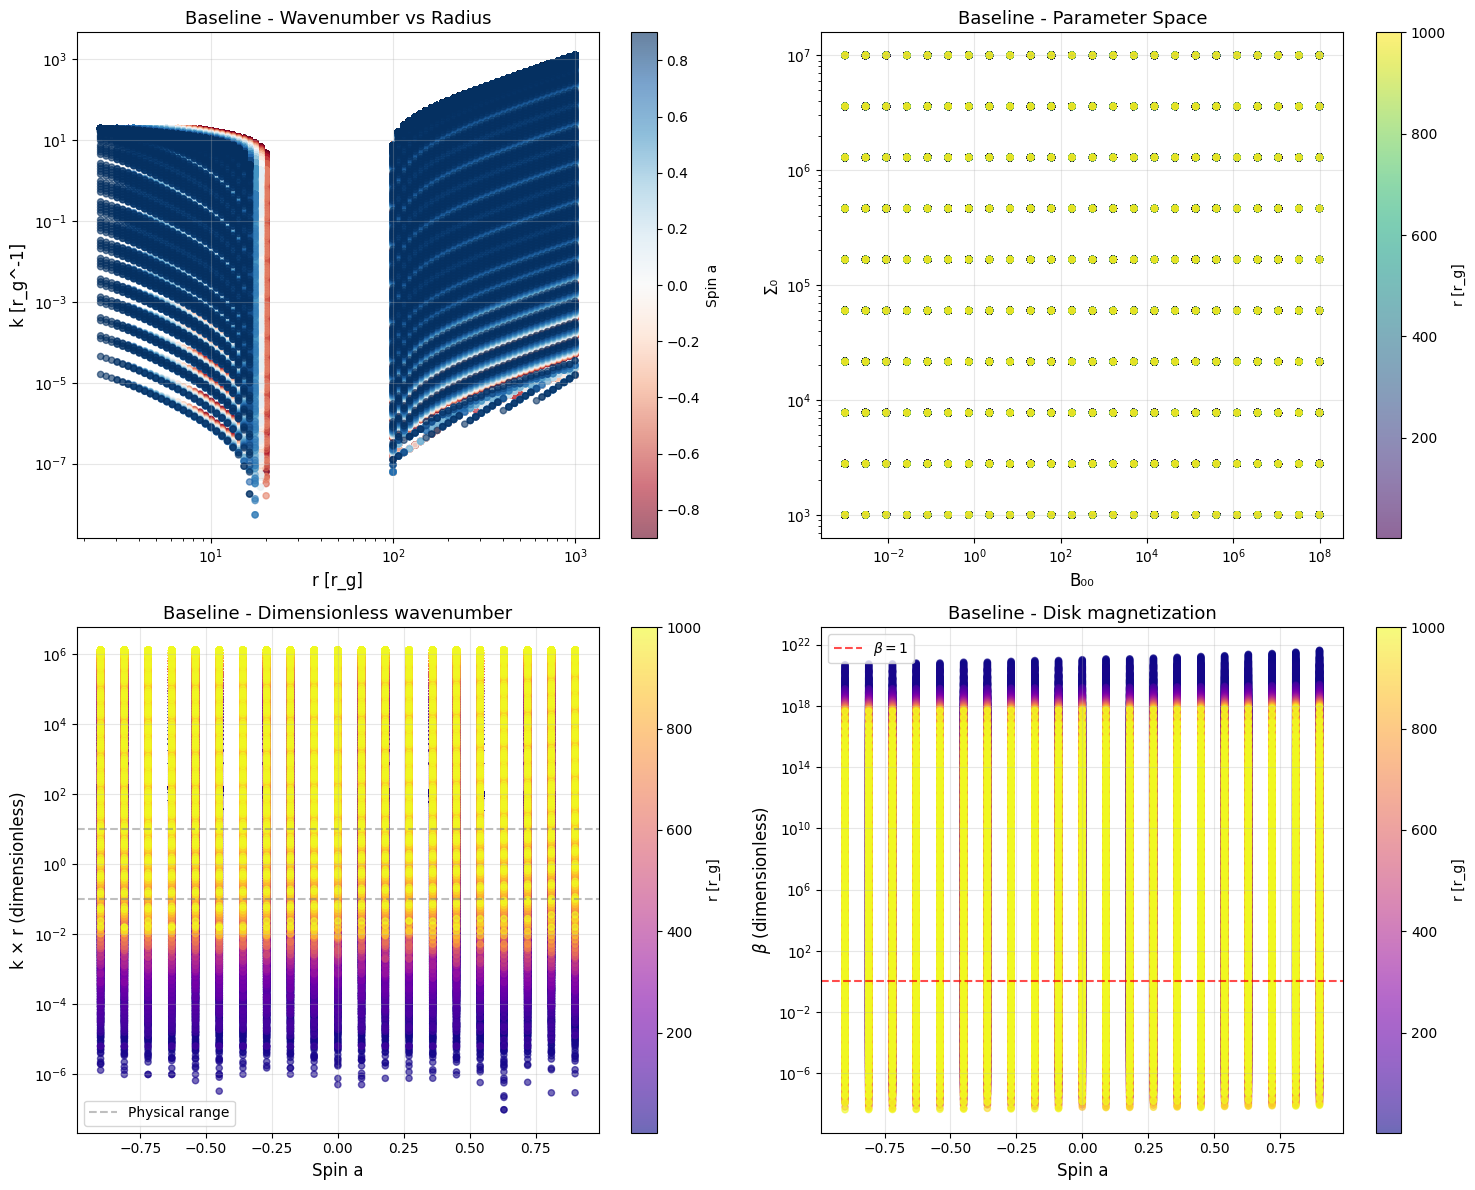


Baseline - Statistiche:
  Numero di soluzioni: 259955
  Range k×r: [0.000, 1268643.752]
  Range β: [4.106e-09, 4.260e+21]
  Range dQ/dr: [-6.316e+10, -3.412e-21]
  Frazione con β ≤ 1: 22.7%
  Frazione con dQ/dr > 0: 0.0%


In [61]:
print("=" * 80)
print("BASELINE: Nessun check fisico (solo validità matematica e ISCO)")
print("=" * 80)

df_baseline = find_rossby_matches(params, use_k_plus=True, 
                                  check_k=False, check_beta=False, check_shear=False)

plot_standard_4panels(df_baseline, "Baseline - ")

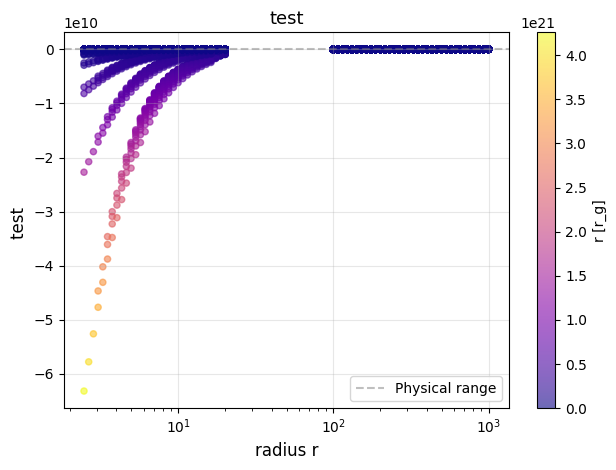

In [62]:
# plotto punti in funzione del raggio, colori dan intensità campo magnetico

if len(df_baseline) > 0:
    sc3 = plt.scatter(df_baseline['r'], df_baseline['dQ_dr'], c=df_baseline['beta'], 
                             alpha=0.6, cmap='plasma', s=20)
    plt.xlabel('radius r', fontsize=12)
    plt.ylabel('test ', fontsize=12)
    plt.xscale('log')
    plt.title(f'test', fontsize=13)
    plt.axhline(1, ls='--', c='gray', alpha=0.5, label='Physical range')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.colorbar(sc3, label='r [r_g]')

    plt.tight_layout()
    plt.show()

### Check 1: Solo Bound su k


CHECK 1: Solo bound fisico su k (0.1/r < k < 10/r)


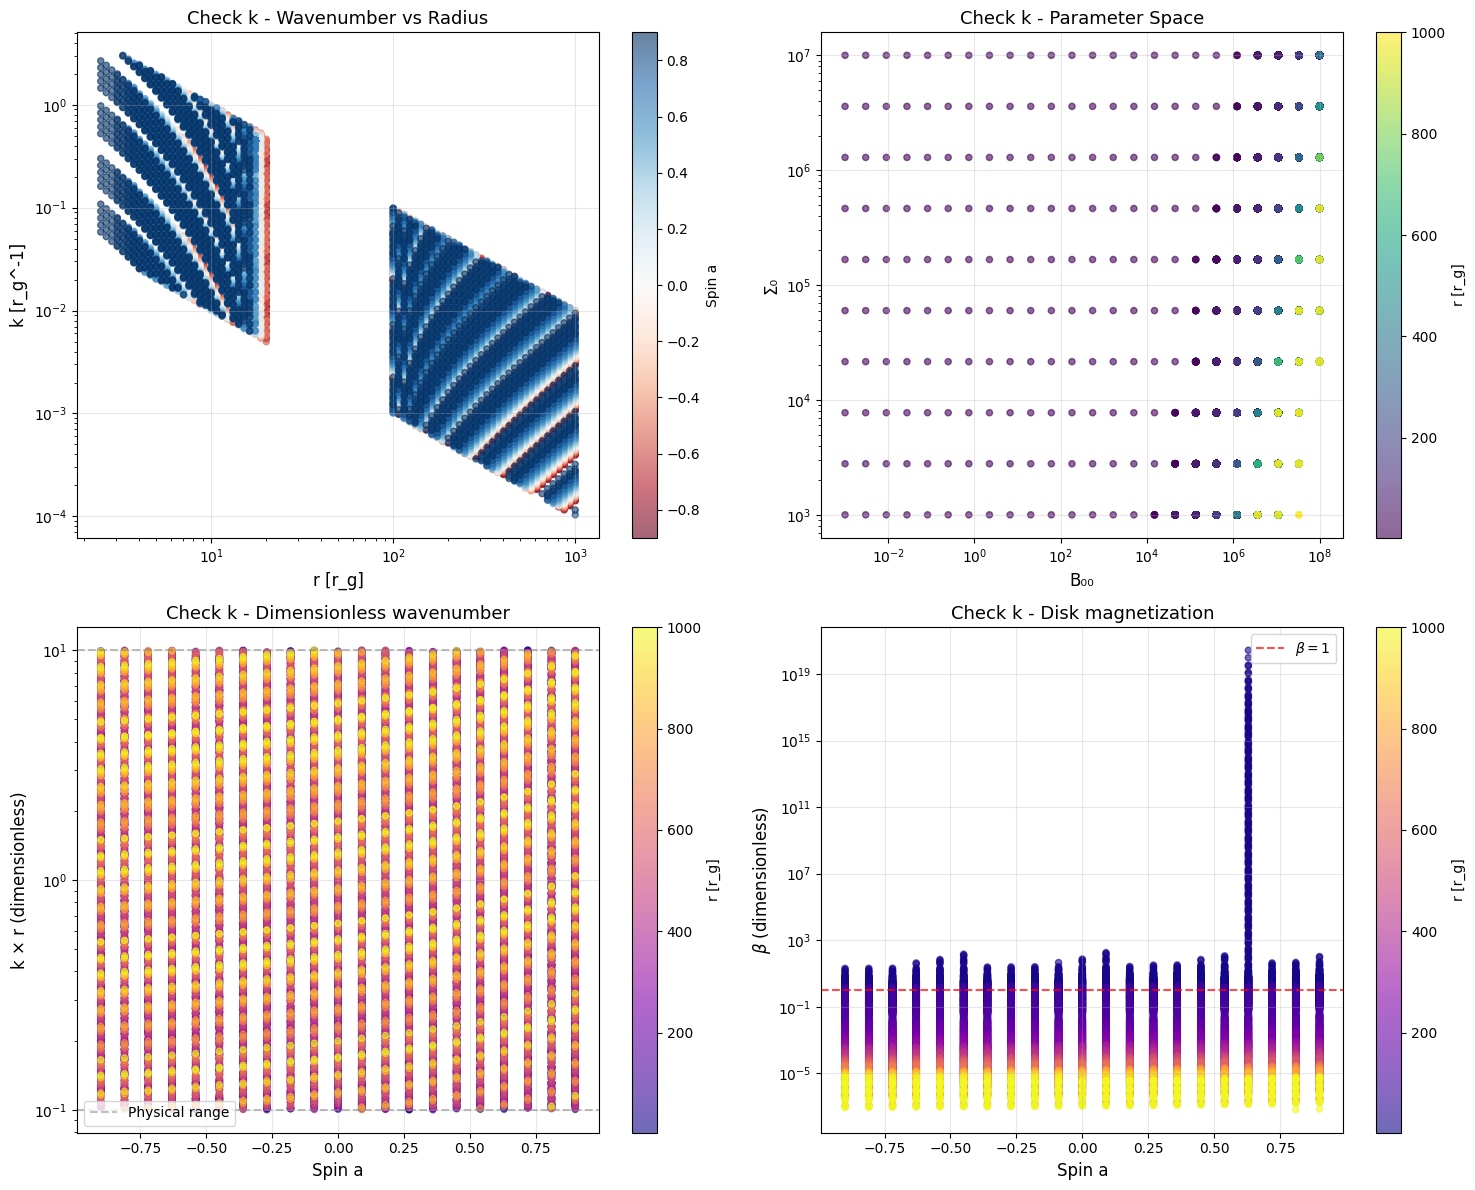


Check k - Statistiche:
  Numero di soluzioni: 20941
  Range k×r: [0.100, 10.000]
  Range β: [6.492e-08, 2.681e+20]
  Range dQ/dr: [-1.678e+09, -5.395e-20]
  Frazione con β ≤ 1: 82.3%
  Frazione con dQ/dr > 0: 0.0%

Riduzione rispetto a baseline: 259955 → 20941 (8.1%)


In [63]:
print("\n" + "=" * 80)
print("CHECK 1: Solo bound fisico su k (0.1/r < k < 10/r)")
print("=" * 80)

df_check_k = find_rossby_matches(params, use_k_plus=True, 
                                check_k=True, check_beta=False, check_shear=False)

plot_standard_4panels(df_check_k, "Check k - ")

print(f"\nRiduzione rispetto a baseline: {len(df_baseline)} → {len(df_check_k)} "
      f"({len(df_check_k)/len(df_baseline)*100:.1f}%)")

### Check 2: Solo Bound su β


CHECK 2: Solo bound su β (β ≤ 1 per instabilità AEI)


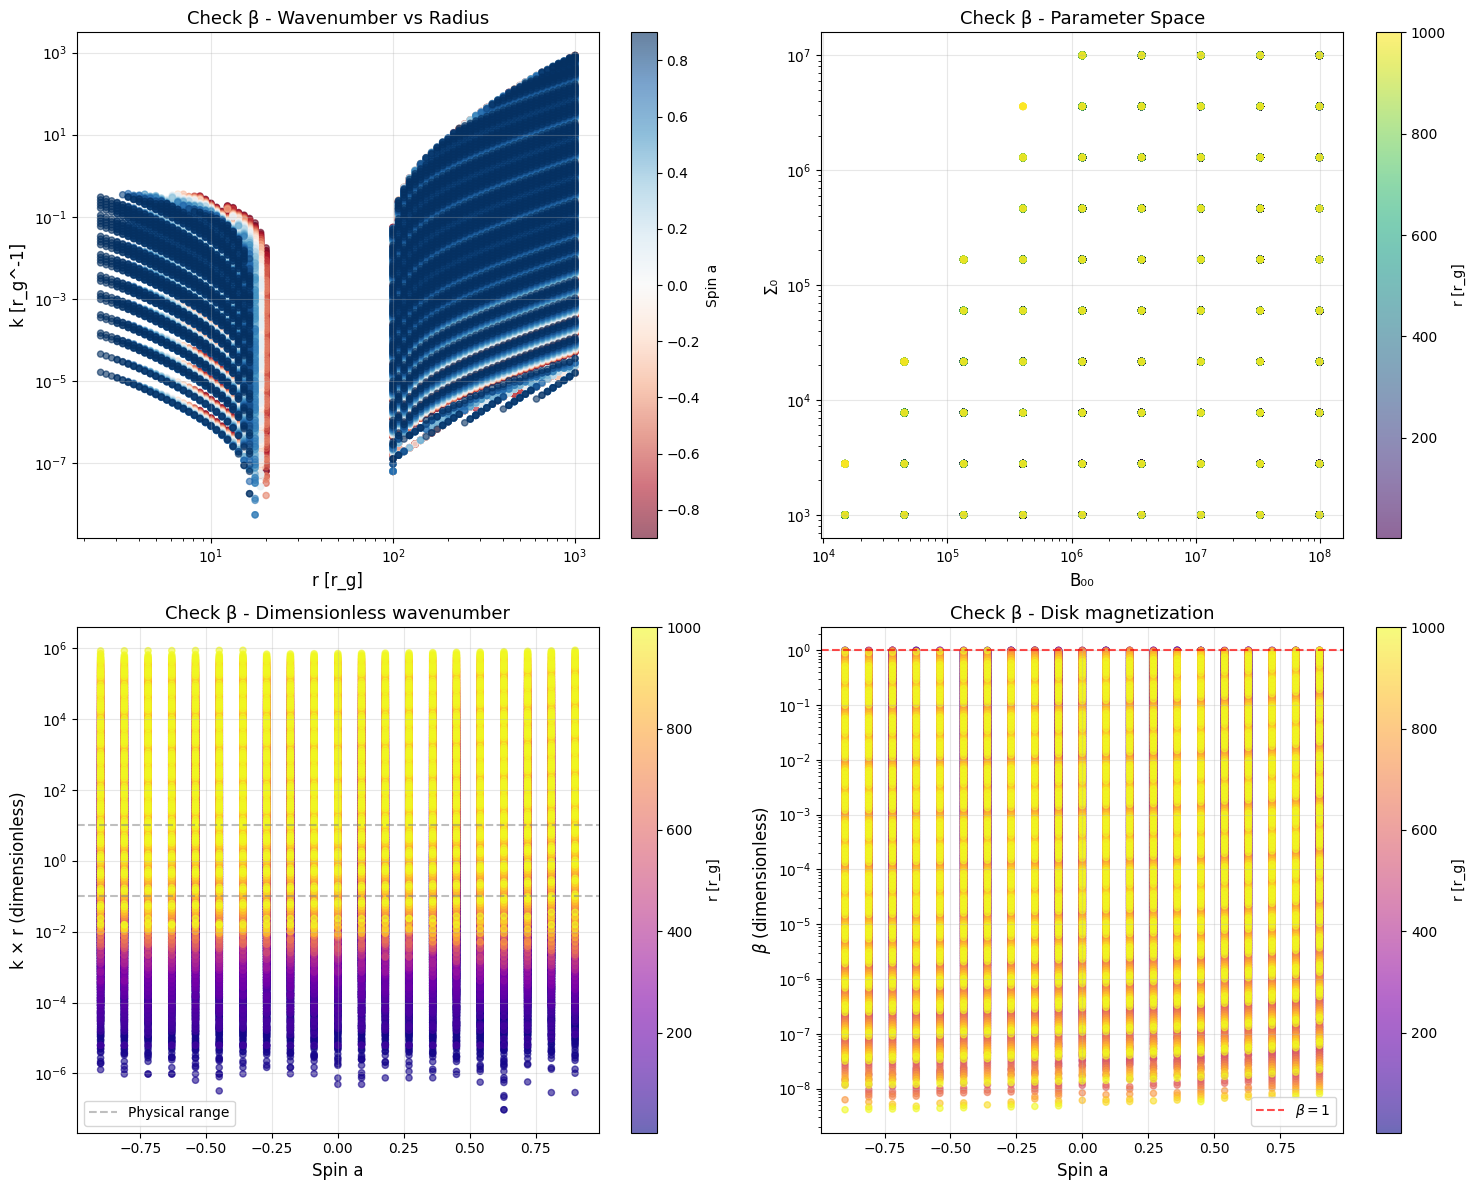


Check β - Statistiche:
  Numero di soluzioni: 58990
  Range k×r: [0.000, 859998.237]
  Range β: [4.106e-09, 9.997e-01]
  Range dQ/dr: [-1.315e-11, -3.412e-21]
  Frazione con β ≤ 1: 100.0%
  Frazione con dQ/dr > 0: 0.0%

Riduzione rispetto a baseline: 259955 → 58990 (22.7%)


In [64]:
print("\n" + "=" * 80)
print("CHECK 2: Solo bound su β (β ≤ 1 per instabilità AEI)")
print("=" * 80)

df_check_beta = find_rossby_matches(params, use_k_plus=True, 
                                   check_k=False, check_beta=True, check_shear=False)

plot_standard_4panels(df_check_beta, "Check β - ")

print(f"\nRiduzione rispetto a baseline: {len(df_baseline)} → {len(df_check_beta)} "
      f"({len(df_check_beta)/len(df_baseline)*100:.1f}%)")

### Check 3: Solo Bound su Shear

In [59]:
print("\n" + "=" * 80)
print("CHECK 3: Solo bound su shear (d/dr[Ωφ × Σ / B₀²] > 0)")
print("=" * 80)

df_check_shear = find_rossby_matches(params, use_k_plus=True, 
                                    check_k=False, check_beta=False, check_shear=True)

plot_standard_4panels(df_check_shear, "Check Shear - ")

print(f"\nRiduzione rispetto a baseline: {len(df_baseline)} → {len(df_check_shear)} "
      f"({len(df_check_shear)/len(df_baseline)*100:.1f}%)")


CHECK 3: Solo bound su shear (d/dr[Ωφ × Σ / B₀²] > 0)
Nessuna soluzione per Check Shear - 

Riduzione rispetto a baseline: 370467 → 0 (0.0%)


### Tutti i Check Combinati

In [29]:
print("\n" + "=" * 80)
print("TUTTI I CHECK COMBINATI")
print("=" * 80)

df_all_checks = find_rossby_matches(params, use_k_plus=True, 
                                   check_k=True, check_beta=True, check_shear=True)

plot_standard_4panels(df_all_checks, "All Checks - ")

print(f"\nRiduzione rispetto a baseline: {len(df_baseline)} → {len(df_all_checks)} "
      f"({len(df_all_checks)/len(df_baseline)*100:.1f}%)")


TUTTI I CHECK COMBINATI


/home/masterpops/IUSS_tesi/setup.py:193: RuntimeWarning: invalid value encountered in sqrt
  factor = np.sqrt(1 - (6)/r + (8*a)/r**1.5 - (3*a**2)/r**2)


Nessuna soluzione per All Checks - 

Riduzione rispetto a baseline: 139377 → 0 (0.0%)


## Confronto Riassuntivo


CONFRONTO RIASSUNTIVO DEGLI EFFETTI DEI BOUND

 Configurazione  N_soluzioni  % rispetto baseline
      Baseline       139377                100.0
        Solo k        12346                  8.9
        Solo β        22985                 16.5
    Solo Shear            0                  0.0
         Tutti            0                  0.0


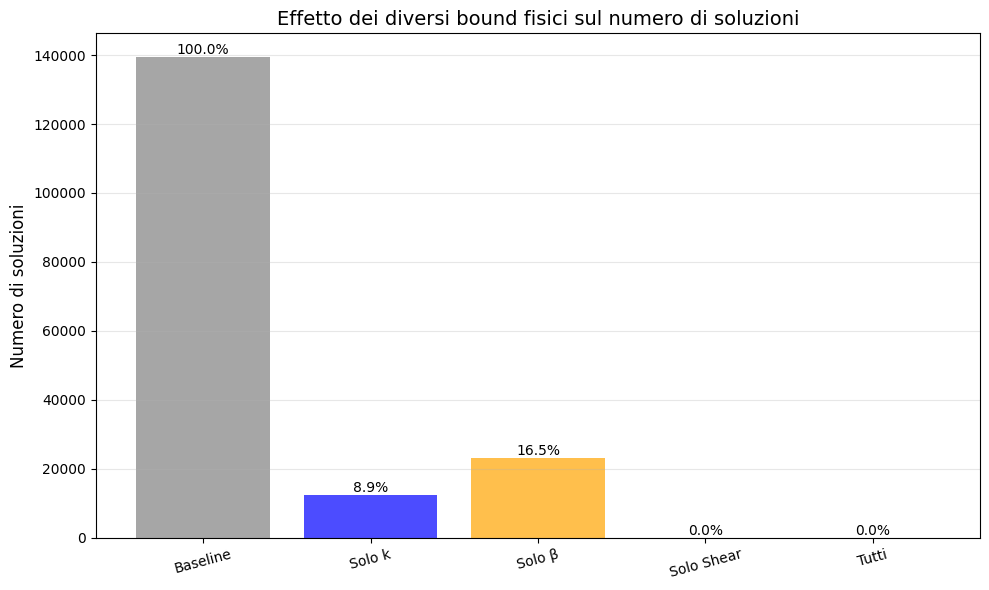

In [30]:
print("\n" + "=" * 80)
print("CONFRONTO RIASSUNTIVO DEGLI EFFETTI DEI BOUND")
print("=" * 80)

comparison = pd.DataFrame({
    'Configurazione': ['Baseline', 'Solo k', 'Solo β', 'Solo Shear', 'Tutti'],
    'N_soluzioni': [len(df_baseline), len(df_check_k), len(df_check_beta), 
                   len(df_check_shear), len(df_all_checks)],
})

comparison['% rispetto baseline'] = (comparison['N_soluzioni'] / len(df_baseline) * 100).round(1)

print("\n", comparison.to_string(index=False))

# Grafico a barre del confronto
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(comparison['Configurazione'], comparison['N_soluzioni'], 
              color=['gray', 'blue', 'orange', 'green', 'red'], alpha=0.7)
ax.set_ylabel('Numero di soluzioni', fontsize=12)
ax.set_title('Effetto dei diversi bound fisici sul numero di soluzioni', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')

# Aggiungi le percentuali sulle barre
for i, (bar, pct) in enumerate(zip(bars, comparison['% rispetto baseline'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{pct:.1f}%',
            ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Analisi Dettagliata: Intersezioni tra i Bound


ANALISI DELLE INTERSEZIONI TRA I BOUND

Combinazioni di check soddisfatti:
  Solo k:           5465
  Solo β:           16104
  Solo shear:       0
  k ∩ β:            6881
  k ∩ shear:        0
  β ∩ shear:        0
  k ∩ β ∩ shear:    0
  Nessuno:          110927


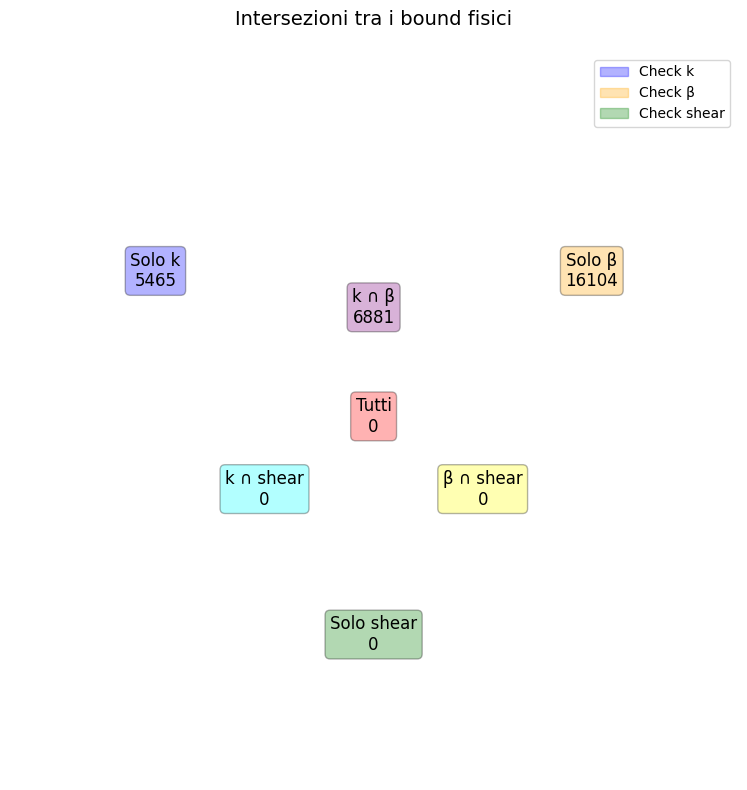

In [31]:
print("\n" + "=" * 80)
print("ANALISI DELLE INTERSEZIONI TRA I BOUND")
print("=" * 80)

# Creiamo un DataFrame con tutte le info sui check per ogni soluzione baseline
df_analysis = df_baseline.copy()

# Aggiungi colonne booleane per ogni check
df_analysis['passes_k'] = check_k_physical(df_analysis['k'].values, df_analysis['r'].values)
df_analysis['passes_beta'] = df_analysis['beta'] <= 1.0
df_analysis['passes_shear'] = df_analysis['dQ_dr'] > 0

# Conta le varie combinazioni
print("\nCombinazioni di check soddisfatti:")
print(f"  Solo k:           {(df_analysis['passes_k'] & ~df_analysis['passes_beta'] & ~df_analysis['passes_shear']).sum()}")
print(f"  Solo β:           {(~df_analysis['passes_k'] & df_analysis['passes_beta'] & ~df_analysis['passes_shear']).sum()}")
print(f"  Solo shear:       {(~df_analysis['passes_k'] & ~df_analysis['passes_beta'] & df_analysis['passes_shear']).sum()}")
print(f"  k ∩ β:            {(df_analysis['passes_k'] & df_analysis['passes_beta'] & ~df_analysis['passes_shear']).sum()}")
print(f"  k ∩ shear:        {(df_analysis['passes_k'] & ~df_analysis['passes_beta'] & df_analysis['passes_shear']).sum()}")
print(f"  β ∩ shear:        {(~df_analysis['passes_k'] & df_analysis['passes_beta'] & df_analysis['passes_shear']).sum()}")
print(f"  k ∩ β ∩ shear:    {(df_analysis['passes_k'] & df_analysis['passes_beta'] & df_analysis['passes_shear']).sum()}")
print(f"  Nessuno:          {(~df_analysis['passes_k'] & ~df_analysis['passes_beta'] & ~df_analysis['passes_shear']).sum()}")

# Diagramma di Venn-style con matplotlib
from matplotlib.patches import Circle
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 8))

# Conta i numeri per ogni regione
only_k = (df_analysis['passes_k'] & ~df_analysis['passes_beta'] & ~df_analysis['passes_shear']).sum()
only_beta = (~df_analysis['passes_k'] & df_analysis['passes_beta'] & ~df_analysis['passes_shear']).sum()
only_shear = (~df_analysis['passes_k'] & ~df_analysis['passes_beta'] & df_analysis['passes_shear']).sum()
k_and_beta = (df_analysis['passes_k'] & df_analysis['passes_beta'] & ~df_analysis['passes_shear']).sum()
k_and_shear = (df_analysis['passes_k'] & ~df_analysis['passes_beta'] & df_analysis['passes_shear']).sum()
beta_and_shear = (~df_analysis['passes_k'] & df_analysis['passes_beta'] & df_analysis['passes_shear']).sum()
all_three = (df_analysis['passes_k'] & df_analysis['passes_beta'] & df_analysis['passes_shear']).sum()

# Testo con i numeri
text_data = [
    (0.2, 0.7, f"Solo k\n{only_k}", 'blue'),
    (0.8, 0.7, f"Solo β\n{only_beta}", 'orange'),
    (0.5, 0.2, f"Solo shear\n{only_shear}", 'green'),
    (0.5, 0.65, f"k ∩ β\n{k_and_beta}", 'purple'),
    (0.35, 0.4, f"k ∩ shear\n{k_and_shear}", 'cyan'),
    (0.65, 0.4, f"β ∩ shear\n{beta_and_shear}", 'yellow'),
    (0.5, 0.5, f"Tutti\n{all_three}", 'red'),
]

for x, y, txt, color in text_data:
    ax.text(x, y, txt, ha='center', va='center', fontsize=12, 
            bbox=dict(boxstyle='round', facecolor=color, alpha=0.3))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Intersezioni tra i bound fisici', fontsize=14, pad=20)

# Legenda
k_patch = mpatches.Patch(color='blue', alpha=0.3, label='Check k')
beta_patch = mpatches.Patch(color='orange', alpha=0.3, label='Check β')
shear_patch = mpatches.Patch(color='green', alpha=0.3, label='Check shear')
ax.legend(handles=[k_patch, beta_patch, shear_patch], loc='upper right')

plt.tight_layout()
plt.show()